# Data Exploration and Visual Exploration Lab

In this lab, you will practice an exploratory workflow using a PM2.5 air-quality dataset from North Carolina.

This lab comes after the lessons on **Data Exploration** and **Visual Data Exploration**. The goal is not just to run code, but to decide what to inspect, interpret what you find, and document your reasoning.

## Learning goals

By the end of this lab, you should be able to:

- Load a CSV file into a Pandas dataframe.
- Inspect dataframe structure, column names, data types, and missing values.
- Explore numeric, categorical, and datetime fields.
- Summarize a numeric variable using descriptive statistics.
- Create exploratory visualizations using Pandas plotting methods.
- Compare plot types and choose appropriate visual tools for different questions.
- Write short interpretations of exploratory results.


## Part 1: Set Up the Session

Load the packages and define the folder paths used in this course project.


In [2]:
# Import packages: Path (from pathlib) and Pandas (as pd)
from pathlib import Path
import pandas as pd

In [3]:
# Set folder paths: project, raw, and processed
root_fldr = Path.cwd().parent.parent
raw_fldr = root_fldr /'assignments'/ 'data' / 'raw'
processed_fldr = root_fldr /'assignments'/ 'data' / 'processed'

## Part 2: Load the Data
Read `EPAair_PM25_NC2025_raw.csv` into a dataframe named `pm25`.

When reading the file:

- Set `Site ID` to use the `category` data type.
- Parse `Date` as a datetime field.
- Use the date format `%m/%d/%Y`.

>Tip: See section 9 in the **M3-1** notebook.

In [4]:
# Read the CSV file into a dataframe named pm25.
pm25 = pd.read_csv(
    raw_fldr/'EPAair_PM25_NC2025_raw.csv',
    dtype={'site_ID':'category'},
    parse_dates=['Date'], 
    date_format="%Y-%m-%d"
    )

In [5]:
# Display the first few rows.
pm25.head()

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2025,AQS,370110002,1,0.7,ug/m3 LC,4,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072
1,01/04/2025,AQS,370110002,1,1.2,ug/m3 LC,7,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072
2,01/07/2025,AQS,370110002,1,1.5,ug/m3 LC,8,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072
3,01/10/2025,AQS,370110002,1,4.2,ug/m3 LC,23,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072
4,01/13/2025,AQS,370110002,1,5.0,ug/m3 LC,28,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072


### Reflection

In one or two sentences, describe what a single row in this dataset appears to represent.

**Your answer:** The date, daily PM2.5, location, 


## Part 3: Inspect the Dataframe Structure

Use dataframe attributes and methods to answer the following questions.

- How many rows and columns are in the dataframe?
- What are the column names?
- What data type is assigned to each column?
- Which columns are numeric?
- Which columns are categorical or text-like?
- Which column is datetime?


In [6]:
# How many rows and columns are in the dataframe?
pm25.shape

(10184, 22)

In [7]:
# What are the column names?
pm25.columns

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='str')

In [8]:
# Display data types and non-null counts for all the columns?
pm25.info()

<class 'pandas.DataFrame'>
RangeIndex: 10184 entries, 0 to 10183
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            10184 non-null  str    
 1   Source                          10184 non-null  str    
 2   Site ID                         10184 non-null  int64  
 3   POC                             10184 non-null  int64  
 4   Daily Mean PM2.5 Concentration  10184 non-null  float64
 5   Units                           10184 non-null  str    
 6   Daily AQI Value                 10184 non-null  int64  
 7   Local Site Name                 10184 non-null  str    
 8   Daily Obs Count                 10184 non-null  int64  
 9   Percent Complete                10184 non-null  float64
 10  AQS Parameter Code              10184 non-null  int64  
 11  AQS Parameter Description       10184 non-null  str    
 12  Method Code                     10128 non-n

### Interpretation

Answer the following based on the output above.

1. How many observations are in the dataset?  
2. How many variables are in the dataset?  
3. Which variable uses a datetime data type?  
4. Why should `Site ID` be stored as a category instead of as a number?  

**Your answers:**
1. 10184 
2. 22
3. Date
4. repeate values


## Part 4: Check for Missing Values

Missing values are important to identify early because they can affect summaries, plots, and later analysis.


In [9]:
# Count missing values in each column.
pm25.isna().sum()

Date                                 0
Source                               0
Site ID                              0
POC                                  0
Daily Mean PM2.5 Concentration       0
Units                                0
Daily AQI Value                      0
Local Site Name                      0
Daily Obs Count                      0
Percent Complete                     0
AQS Parameter Code                   0
AQS Parameter Description            0
Method Code                         56
Method Description                  56
CBSA Code                         1500
CBSA Name                         1500
State FIPS Code                      0
State                                0
County FIPS Code                     0
County                               0
Site Latitude                        0
Site Longitude                       0
dtype: int64

In [31]:
# Optional: Calculate the percentage of records missing in each column.
# Hint: divide the missing-value counts by the number of rows and multiply by 100.

# Your code here
print(pm25["Source"])
pm25["Source"].value_counts()

0        AQS
1        AQS
2        AQS
3        AQS
4        AQS
        ... 
10179    AQS
10180    AQS
10181    AQS
10182    AQS
10183    AQS
Name: Source, Length: 10184, dtype: str


Source
AQS       10128
AirNow       56
Name: count, dtype: int64

### Interpretation

1. Which columns, if any, contain missing values?  
2. Are the missing values likely to affect the initial exploration? Why or why not?  

**Your answers:**
Method Code, Method Description, CBSA Code, CBSA Name. No because not actual information.                        

## Part 5: Explore a Numeric Variable

The main numeric variable in this dataset is daily mean PM2.5 concentration.

Use the column:

```python
"Daily Mean PM2.5 Concentration"
```


In [11]:
# Store the concentration column name in a shorter variable for reuse.
conc_col = "Daily Mean PM2.5 Concentration"

In [12]:
# Display descriptive statistics for daily mean PM2.5 concentration.
pm25.describe()

,Site ID,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,1.018400e+04,10184.000000,10184.000000,10184.000000,10184.0,10184.0,10184.000000,10128.000000,8684.000000,10184.0,10184.000000,10184.000000,10184.000000
mean,3.710034e+08,3.104183,7.097840,36.877455,1.0,100.0,88125.058425,306.679996,30651.446338,37.0,100.335035,35.610754,-80.033626
std,4.968662e+05,0.847527,3.700242,15.154256,0.0,0.0,95.233981,194.997853,13480.755553,0.0,49.687742,0.474621,1.757147
min,3.701100e+08,1.000000,-1.800000,0.000000,1.0,100.0,88101.000000,145.000000,11700.000000,37.0,11.000000,34.364167,-83.442133
25%,3.706300e+08,3.000000,4.500000,25.000000,1.0,100.0,88101.000000,209.000000,16740.000000,37.0,63.000000,35.281791,-81.365556
50%,3.711900e+08,3.000000,6.500000,36.000000,1.0,100.0,88101.000000,209.000000,25860.000000,37.0,119.000000,35.641276,-80.224501
75%,3.712900e+08,3.000000,9.025000,50.250000,1.0,100.0,88101.000000,209.000000,40580.000000,37.0,129.000000,35.988278,-78.574167
max,3.718300e+08,5.000000,43.700000,121.000000,1.0,100.0,88502.000000,707.000000,49180.000000,37.0,183.000000,36.511708,-76.207165


In [13]:
# Compute the mean and median separately.
mean_pm25 =pm25['Daily Mean PM2.5 Concentration'].mean()
median_pm25 = pm25['Daily Mean PM2.5 Concentration'].median()
print(mean_pm25,median_pm25)

7.097839748625294 6.5


In [14]:
# Print the values
print("Mean PM2.5:", mean_pm25)
print("Median PM2.5:", median_pm25)

Mean PM2.5: 7.097839748625294
Median PM2.5: 6.5


* Use the [quantiles](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html) method to display the quantiles of the dataframe. Adjust the command to show the highest and lowest 20th percentile (4.1 and 9.7, respectively).

In [15]:
# Compute selected quantiles.
pm25[conc_col].quantile([0.25, 0.50, 0.75, 0.95])

0.25     4.500
0.50     6.500
0.75     9.025
0.95    13.500
Name: Daily Mean PM2.5 Concentration, dtype: float64

### Interpretation

1. What is the minimum daily mean PM2.5 concentration?  
2. What is the maximum daily mean PM2.5 concentration?  
3. Is the mean larger or smaller than the median?  
4. What might the relationship between the mean and median suggest about the shape of the distribution?  
5. In what units are PM2.5 concentrations reported?  

**Your answers:**


## Part 6: Explore Categorical Variables

Categorical variables often describe groups, locations, sources, or measurement types.

Start with `Site ID` and `County`.


In [16]:
# How many unique monitoring sites are included?
pm25["Site ID"].unique()

array([370110002, 370210034, 370350004, 370510009, 370570002, 370630015,
       370650099, 370670022, 370670030, 370810013, 370870035, 370959000,
       371010002, 371190041, 371190045, 371190048, 371210004, 371230001,
       371290002, 371310003, 371470006, 371590021, 371730002, 371730007,
       371830014, 371830021])

In [17]:
# List the unique Site ID categories?
pm25["Site ID"].unique()

array([370110002, 370210034, 370350004, 370510009, 370570002, 370630015,
       370650099, 370670022, 370670030, 370810013, 370870035, 370959000,
       371010002, 371190041, 371190045, 371190048, 371210004, 371230001,
       371290002, 371310003, 371470006, 371590021, 371730002, 371730007,
       371830014, 371830021])

In [18]:
# Count records by county.
pm25["County"].value_counts()

County
Mecklenburg    1226
Forsyth         895
Wake            840
Buncombe        762
New Hanover     709
Catawba         695
Swain           614
Durham          585
Davidson        398
Pitt            362
Guilford        360
Mitchell        359
Edgecombe       358
Cumberland      357
Montgomery      354
Northampton     353
Johnston        352
Rowan           352
Avery            87
Hyde             86
Haywood          80
Name: count, dtype: int64

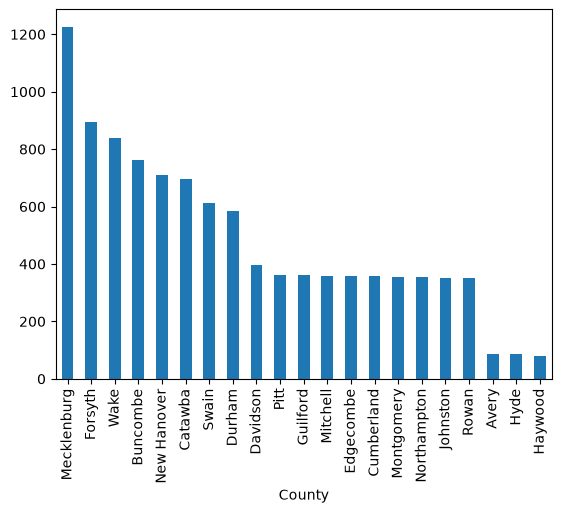

In [19]:
# Create a simple bar plot showing the number of records by county.
# Hint: combine value_counts() with Pandas .plot(kind='bar').
pm25['County'].value_counts().plot(kind='bar');


### Interpretation

1. How many different monitoring sites are included?  
2. Which source contributes the most observations?  
3. Are observations balanced across sources?  
4. Why might an unbalanced number of observations matter when comparing groups?  

**Your answers:**
1. 20
2. Mecklenburg
3. no 
4. different levels of accuracy 


## Part 7: Explore the Datetime Field

Datetime fields have useful sub-components such as year, month, day, and day of week.


In [20]:
# What date range is covered by the dataset? Print the earliest and latest dates in the dataset
pm25["Date"].min(), pm25["Date"].max()


('01/01/2025', '12/31/2025')

In [28]:
# Count observations by month.
print(type(pm25["Date"]))


<class 'pandas.Series'>


In [ ]:
# Optional: Create a month column for later exploration.


### Interpretation

1. What time period is covered by this dataset?  
2. Does the dataset appear to cover a full calendar year?  
3. Are observations evenly distributed across months?  

**Your answers:**


## Part 8: Visualize the Distribution of PM2.5

Start by visualizing the distribution of daily mean PM2.5 concentrations.


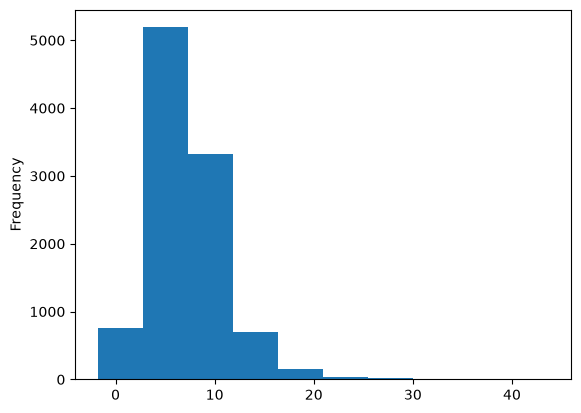

In [23]:
# Create a histogram of daily mean PM2.5 concentration using Pandas plotting.
# Hint: select the concentration Series and use .plot(kind='hist').
pm25['Daily Mean PM2.5 Concentration'].plot(kind='hist');


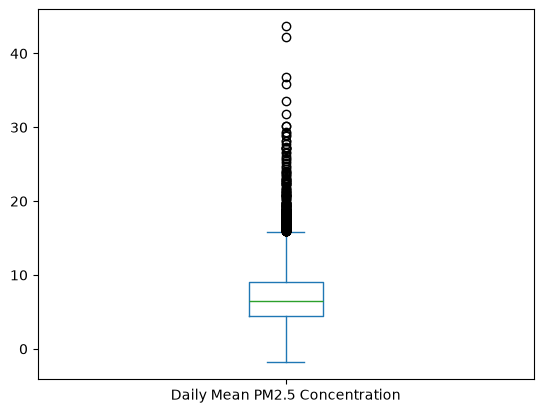

In [24]:
# Create a box plot of daily mean PM2.5 concentration using Pandas plotting.
# Hint: select the concentration Series and use .plot(kind='box').
pm25['Daily Mean PM2.5 Concentration'].plot(kind='box');


### Interpretation

1. Is the distribution symmetric, left-skewed, or right-skewed?  
2. Are there possible outliers?  
3. Which plot made it easier to see the overall shape of the distribution?  
4. Which plot made it easier to identify unusually high values?  

**Your answers:**
Right-skewed
yes 
hist
box

## Part 9: Compare PM2.5 by Source

Now compare daily mean PM2.5 concentration across measurement sources.

Create several visualizations, then decide which one is most useful for comparison.

>Below is code to transform the data such that concentration values are separated into different columns based on their source type ("AQS" or "AirNow"). We'll examine this code later, but you will need this format to produce the KDE plot.

In [25]:
#Transform data so concentration values are in separate columns by Source
pm25_wide = pm25.pivot_table(
    index = ['Site ID','Date'],
    columns = 'Source',
    values = conc_col,
    aggfunc = 'mean'
).reset_index()

#Show the data
pm25_wide.head()

Source,Site ID,Date,AQS,AirNow
0,370110002,01/01/2025,0.7,NaN
1,370110002,01/04/2025,1.2,NaN
2,370110002,01/07/2025,1.5,NaN
3,370110002,01/10/2025,4.2,NaN
4,370110002,01/13/2025,5.0,NaN


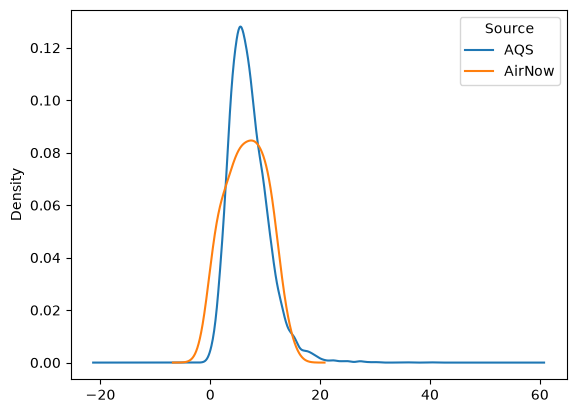

In [32]:
# Create overlaid density (KDE) curves comparing PM2.5 concentration by source. 
# Use Pandas .plot(kind='kde').
pm25_wide[['AQS','AirNow']].plot(kind='kde');

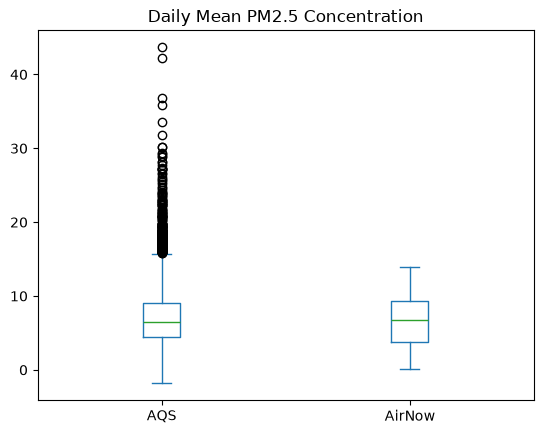

In [36]:
# Create a box plot comparing PM2.5 concentration by source.
# Hint: use Pandas .plot(kind='box', by='Source') or DataFrame.boxplot().
pm25[['Daily Mean PM2.5 Concentration','Source']].plot(kind='box',by='Source');


Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


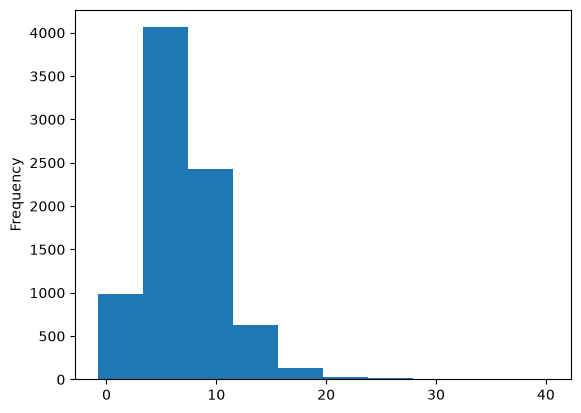

In [41]:
# Create histograms of PM2.5 concentration for each source.
# Use Pandas plotting to compare the distributions. You may create separate plots or overlay them.
print(pm25_wide['AQS'].plot(kind='hist'));
print(pm25_wide['AirNow'].plot(kind='hist'));

## Part 11: Data Exploration Checklist

Use this checklist when exploring a new dataset.

- [ ] Load the data and confirm it imported correctly.
- [ ] Examine rows, columns, and column names.
- [ ] Inspect data types.
- [ ] Identify missing values.
- [ ] Summarize numeric variables.
- [ ] Examine categorical variables.
- [ ] Explore datetime variables.
- [ ] Visualize distributions.
- [ ] Compare groups when relevant.
- [ ] Document unusual observations.
- [ ] Write short conclusions in plain language.
